# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [27]:
from pathlib import Path
import json
import sys

try:
    import numpy as np
    import pandas as pd
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Установите зависимости командой: "
        "python -m pip install -r requirements_delivery.txt"
    ) from exc

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string() if hasattr(value, "to_string") else value)

# Для скрипта - его папка; для ноутбука - текущая рабочая папка.
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_PATH = BASE_DIR / "delivery_dataset.csv"
OUTPUT_DIR = BASE_DIR / "delivery_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Не найден файл {DATA_PATH}. "
        "Положите delivery_dataset.csv в папку с решением."
    )

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Пропуски: {int(df.isna().sum().sum())}")
print(f"Полные дубликаты строк: {int(df.duplicated().sum())}")
display(df)

Размер данных: 500 строк, 8 столбцов
Пропуски: 0
Полные дубликаты строк: 0


,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2
...,...,...,...,...,...,...,...,...
495,2026-08-12,ORD-202608496,5.2,2,3,18.0,9,28.9
496,2026-08-09,ORD-202608497,10.0,3,4,21.6,10,48.0
497,2026-08-07,ORD-202608498,5.5,3,2,9.5,3,27.0
498,2026-08-28,ORD-202608499,7.1,6,4,13.5,1,40.4


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [28]:
FEATURE_COLUMNS = ['Расстояние до клиента (в км)', 'Количество позиций в чеке (в шт.)', 'Балл пробок на дорогах (в баллах)', 'Погода (в градусах Цельсия)', 'Этаж доставки (в этажах)']
TARGET_COLUMN = 'Время доставки (в минутах)'
ID_COLUMN = 'Шифр заказа (ID)'
DATE_COLUMN = 'Дата заказа (ГГГГ-ММ-ДД)'


# По условию нужно ровно 500 заказов и разбиение 300 / 100 / 100.
if len(df) != 500:
    raise ValueError(f"Ожидалось 500 строк, получено: {len(df)}")
required = FEATURE_COLUMNS + [TARGET_COLUMN, ID_COLUMN, DATE_COLUMN]
missing_columns = [col for col in required if col not in df.columns]
if missing_columns:
    raise ValueError(f"Не хватает столбцов: {missing_columns}")
if df[required].isna().any().any():
    raise ValueError("В данных есть пропуски: нужно отдельно решить, как их обработать.")
if df[ID_COLUMN].duplicated().any():
    raise ValueError("Найдены повторы ИД заказов: проверьте независимость выборок.")

numeric_values = df[FEATURE_COLUMNS + [TARGET_COLUMN]].to_numpy(dtype=float)
if not np.isfinite(numeric_values).all():
    raise ValueError("Числовые данные должны быть конечными.")

# Не перемешиваем и не сортируем данные по дате.
train_df = df.iloc[:300].copy()
val_df = df.iloc[300:400].copy()
test_df = df.iloc[400:500].copy()

X_train = train_df[FEATURE_COLUMNS].astype(float)
y_train = train_df[TARGET_COLUMN].astype(float)
X_val = val_df[FEATURE_COLUMNS].astype(float)
y_val = val_df[TARGET_COLUMN].astype(float)
X_test = test_df[FEATURE_COLUMNS].astype(float)
y_test = test_df[TARGET_COLUMN].astype(float)

assert set(train_df.index).isdisjoint(val_df.index)
assert set(train_df.index).isdisjoint(test_df.index)
assert set(val_df.index).isdisjoint(test_df.index)

split_info = pd.DataFrame({
    "split": ["train", "val", "test"],
    "orders": [len(train_df), len(val_df), len(test_df)],
    "row_numbers": ["1-300", "301-400", "401-500"],
    "features": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
})
display(split_info)
print("Признаки модели:", FEATURE_COLUMNS)
print("Целевой столбец:", TARGET_COLUMN)

,split,orders,row_numbers,features
0,train,300,1-300,5
1,val,100,301-400,5
2,test,100,401-500,5


Признаки модели: ['Расстояние до клиента (в км)', 'Количество позиций в чеке (в шт.)', 'Балл пробок на дорогах (в баллах)', 'Погода (в градусах Цельсия)', 'Этаж доставки (в этажах)']
Целевой столбец: Время доставки (в минутах)


#### Вопрос 1. 

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировачная, для чего валидационная, для чего тестовая?

#### Ответ

Разбиваем для того, чтобы проверить то, как модель описала известные данные и как она работает на заказах, которые не участвовали в обучении.

Тренировочная выборка нужна для обучения модели, по этим данным она подбирает коэффициенты для предсказания времени доставки. Валидационная - для проверки ошибок во время обучения и выбора настроек модели. Тестовая - для итоговой проверки на данных, которые не использовались при обучении и выборе настроек.

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [29]:
%pip install scikit-learn

from sklearn.linear_model import Ridge
import sklearn

Note: you may need to restart the kernel to use updated packages.


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [30]:
# Регуляризация отключена: решаем задачу обычной линейной регрессии.
ALPHA = 0.0
TOL = 1e-10
MAX_ITER = 1000

model = Ridge(
    alpha=ALPHA,
    solver="sparse_cg",
    fit_intercept=True,
    tol=TOL,
    max_iter=MAX_ITER,
)
model.fit(X_train, y_train)

coefficients = pd.DataFrame({
    "feature": ["intercept"] + FEATURE_COLUMNS,
    "coefficient": [float(model.intercept_)] + model.coef_.tolist(),
})
display(coefficients)
coefficients.to_csv(OUTPUT_DIR / "model_coefficients.csv", index=False, encoding="utf-8-sig")

,feature,coefficient
0,intercept,-2.967328
1,Расстояние до клиента (в км),4.396127
2,Количество позиций в чеке (в шт.),0.835327
3,Балл пробок на дорогах (в баллах),2.153894
4,Погода (в градусах Цельсия),-0.047348
5,Этаж доставки (в этажах),0.343231


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.


,iteration,train_SSE,val_SSE,train_MSE,val_MSE,train_RMSE,val_RMSE,residual_norm
0,0,211009.701867,72207.381378,703.365673,722.073814,26.521042,26.871431,45008.929310
1,1,12930.233097,3662.411544,43.100777,36.624115,6.565118,6.051786,4701.892597
2,2,9382.164498,2919.239968,31.273882,29.192400,5.592306,5.402999,3399.116172
3,3,6077.896168,2109.703091,20.259654,21.097031,4.501073,4.593150,1618.783425
4,4,5728.926281,2075.766273,19.096421,20.757663,4.369945,4.556058,794.339223
5,5,5529.134406,2078.505245,18.430448,20.785052,4.293070,4.559063,0.000000


Число итераций CG: 5
Максимальное отличие весов от Ridge: 3.1086244689504383e-15


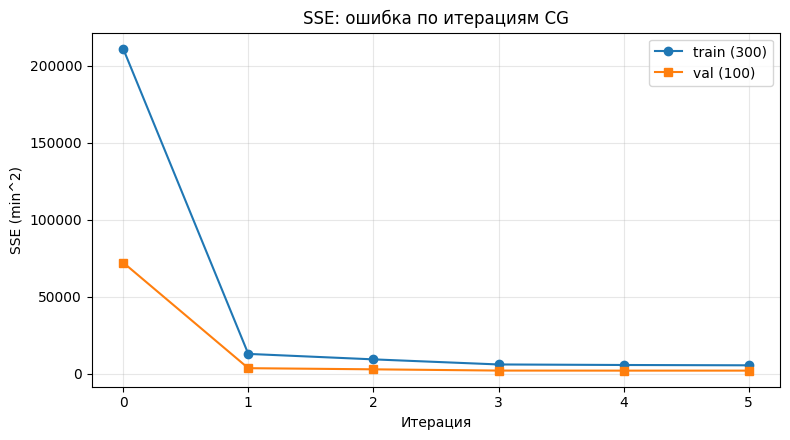

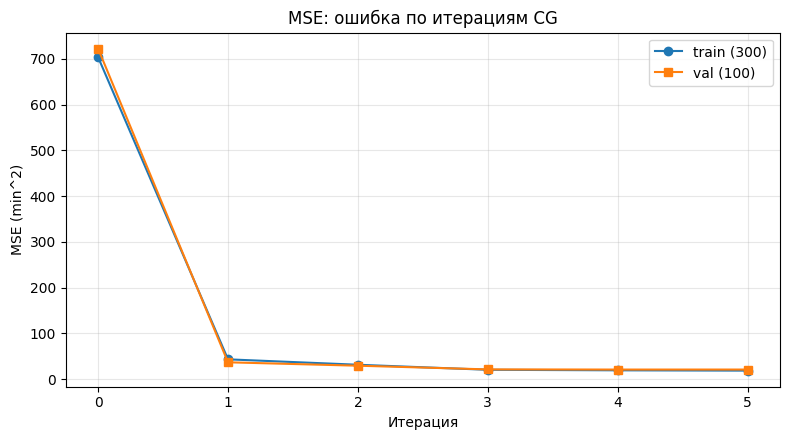

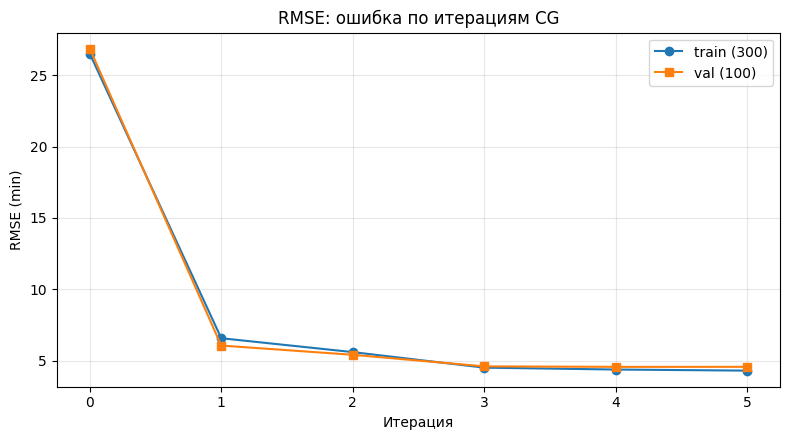

In [31]:
import matplotlib.pyplot as plt
from scipy.sparse.linalg import cg


def regression_metrics(y_true, y_pred):
    """Ошибки в исходных единицах; больше ошибка - хуже прогноз."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.ndim != 1 or y_true.shape != y_pred.shape or y_true.size == 0:
        raise ValueError("Нужны два непустых одномерных вектора одной длины.")
    if not (np.isfinite(y_true).all() and np.isfinite(y_pred).all()):
        raise ValueError("Ответы и прогнозы должны быть конечными.")
    error = y_pred - y_true
    sse = float(error @ error)
    mse = sse / y_true.size
    return {"SSE": sse, "MSE": mse, "RMSE": float(np.sqrt(mse)),
            "MAE": float(np.mean(np.abs(error)))}


X_train_np = X_train.to_numpy()
X_val_np = X_val.to_numpy()
X_mean = X_train_np.mean(axis=0)
y_mean = float(y_train.mean())
X_centered = X_train_np - X_mean
y_centered = y_train.to_numpy() - y_mean
A = X_centered.T @ X_centered + ALPHA * np.eye(X_train.shape[1])
b = X_centered.T @ y_centered

# Для этого набора данных матрица должна быть положительно определенной.
if np.linalg.eigvalsh(A).min() <= 0:
    raise ValueError("Матрица не положительно определена: проверьте линейную зависимость признаков.")

history_rows = []


def save_iteration(weights):
    """Веса обновляются по train; val нужен только для наблюдения."""
    pred_train = (X_train_np - X_mean) @ weights + y_mean
    pred_val = (X_val_np - X_mean) @ weights + y_mean
    metrics_train = regression_metrics(y_train, pred_train)
    metrics_val = regression_metrics(y_val, pred_val)
    row = {"iteration": len(history_rows)}
    for metric in ("SSE", "MSE", "RMSE"):
        row[f"train_{metric}"] = metrics_train[metric]
        row[f"val_{metric}"] = metrics_val[metric]
    row["residual_norm"] = float(np.linalg.norm(b - A @ weights))
    history_rows.append(row)


initial_weights = np.zeros(X_train.shape[1])
save_iteration(initial_weights)
weights_cg, cg_info = cg(
    A, b,
    x0=initial_weights,
    rtol=TOL,
    atol=0.0,
    maxiter=MAX_ITER,
    callback=save_iteration,
)
if cg_info != 0:
    raise RuntimeError(f"Метод CG не сошелся, код: {cg_info}")

intercept_cg = y_mean - X_mean @ weights_cg
np.testing.assert_allclose(weights_cg, model.coef_, rtol=1e-8, atol=1e-8)
np.testing.assert_allclose(intercept_cg, model.intercept_, rtol=1e-8, atol=1e-8)

history = pd.DataFrame(history_rows)
display(history.round(6))
print("Число итераций CG:", len(history) - 1)
print("Максимальное отличие весов от Ridge:", np.max(np.abs(weights_cg - model.coef_)))
history.to_csv(OUTPUT_DIR / "cg_history.csv", index=False, encoding="utf-8-sig")

# Для каждой метрики - отдельный график. Масштаб оси Y линейный.
y_labels = {"SSE": "SSE (min^2)", "MSE": "MSE (min^2)", "RMSE": "RMSE (min)"}
for metric in ("SSE", "MSE", "RMSE"):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(history["iteration"], history[f"train_{metric}"], marker="o", label="train (300)")
    ax.plot(history["iteration"], history[f"val_{metric}"], marker="s", label="val (100)")
    ax.set_title(f"{metric}: ошибка по итерациям CG")
    ax.set_xlabel("Итерация")
    ax.set_ylabel(y_labels[metric])
    ax.set_xticks(history["iteration"])
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{metric.lower()}_by_iteration.png", dpi=160)
    plt.show()
    plt.close(fig)

#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

#### Ответ

Во время обучения ошибки на тренировочной и валидационной выборках уменьшились, а к концу почти перестали меняться (модель стала точнее предсказывать время доставки).

#### Вопрос 3. 

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

#### Ответ

Недообученная модель: обе ошибки высокие, потому что модель плохо описывает зависимость между признаками и временем доставки.

Обученная модель: обе ошибки уменьшаются, затем почти перестают меняться и остаются на приемлемом уровне без большого разрыва.

Переобученная модель: ошибка train низкая, а ошибка val заметно выше и может расти. Модель хорошо подстроилась под обучающие данные, но хуже предсказывает новые.

#### Шаг 6. Применение модели на тестовой выборке

In [32]:
# Test используем только после завершения обучения.
y_pred_test = model.predict(X_test)

test_predictions = test_df.copy()
test_predictions.insert(0, "row_number", test_df.index.to_numpy() + 1)
test_predictions["predicted_minutes"] = y_pred_test
# Знак ошибки: прогноз минус факт. Плюс - время завышено.
test_predictions["error_minutes"] = y_pred_test - y_test.to_numpy()
test_predictions["absolute_error_minutes"] = np.abs(test_predictions["error_minutes"])

prediction_path = OUTPUT_DIR / "test_predictions.csv"
test_predictions.to_csv(prediction_path, index=False, encoding="utf-8-sig")
print(f"Сохранены прогнозы для {len(test_predictions)} заказов:", prediction_path)
display(test_predictions[[ID_COLUMN, TARGET_COLUMN, "predicted_minutes", "error_minutes",
                          "absolute_error_minutes"]].head(15).round(4))

Сохранены прогнозы для 100 заказов: c:\Users\Nik\Downloads\delivery_results\test_predictions.csv


,Шифр заказа (ID),Время доставки (в минутах),predicted_minutes,error_minutes,absolute_error_minutes
400,ORD-202608401,33.9,33.0662,-0.8338,0.8338
401,ORD-202608402,33.1,33.1255,0.0255,0.0255
402,ORD-202608403,16.3,20.8522,4.5522,4.5522
403,ORD-202608404,34.7,34.3852,-0.3148,0.3148
404,ORD-202608405,13.3,17.5623,4.2623,4.2623
405,ORD-202608406,39.3,42.8093,3.5093,3.5093
406,ORD-202608407,36.3,37.4487,1.1487,1.1487
407,ORD-202608408,11.9,12.3472,0.4472,0.4472
408,ORD-202608409,56.5,59.0543,2.5543,2.5543
409,ORD-202608410,35.9,32.0826,-3.8174,3.8174


#### Шаг 7. RMSE на тестовой выборке

In [33]:
from sklearn.metrics import mean_squared_error

# Главный резултат шага 7: RMSE на 100 тестовых заказах.
test_metrics = regression_metrics(y_test, y_pred_test)
rmse_test = test_metrics["RMSE"]
np.testing.assert_allclose(rmse_test, np.sqrt(mean_squared_error(y_test, y_pred_test)))
print(f"RMSE test: {rmse_test:.6f} мин")

# Дополнительно сравниваем выборки и базовый прогноз средним по train.
metrics_rows = []
for split_name, X_part, y_part in (
    ("train", X_train, y_train),
    ("val", X_val, y_val),
    ("test", X_test, y_test),
):
    pred = model.predict(X_part)
    row = {"split": split_name, "n": len(y_part), **regression_metrics(y_part, pred)}
    baseline_pred = np.full(len(y_part), float(y_train.mean()))
    row["baseline_RMSE"] = regression_metrics(y_part, baseline_pred)["RMSE"]
    metrics_rows.append(row)

metrics_table = pd.DataFrame(metrics_rows).set_index("split")
display(metrics_table.round(6))
metrics_table.to_csv(OUTPUT_DIR / "metrics.csv", encoding="utf-8-sig")

summary = {
    "input_file": DATA_PATH.name,
    "n_rows": len(df),
    "split_sizes": {"train": len(y_train), "val": len(y_val), "test": len(y_test)},
    "features": FEATURE_COLUMNS,
    "target": TARGET_COLUMN,
    "model": {"class": "Ridge", "solver": "sparse_cg", "alpha": ALPHA,
              "fit_intercept": True, "tol": TOL, "max_iter": MAX_ITER},
    "coefficients": model.coef_.tolist(),
    "intercept": float(model.intercept_),
    "cg_iterations": len(history) - 1,
    "cg_info": int(cg_info),
    "max_coefficient_difference": float(np.max(np.abs(weights_cg - model.coef_))),
    "metrics": metrics_table.to_dict(orient="index"),
    "versions": {"Python": sys.version.split()[0], "numpy": np.__version__,
                 "pandas": pd.__version__, "scikit-learn": sklearn.__version__},
}
(OUTPUT_DIR / "summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Файлы результатов:", OUTPUT_DIR)

RMSE test: 4.831132 мин


,n,SSE,MSE,RMSE,MAE,baseline_RMSE
split,,,,,,
train,300,5529.134406,18.430448,4.293070,3.154390,26.521042
val,100,2078.505245,20.785052,4.559063,3.431788,26.871431
test,100,2333.983547,23.339835,4.831132,3.507436,25.957941


Файлы результатов: c:\Users\Nik\Downloads\delivery_results


#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

#### Ответ

На тестовой выборке RMSE составил 4,83 минуты. Этот показатель характеризует величину ошибки и сильнее учитывает большие промахи. Результат близок к ошибкам train и val, поэтому явных признаков сильного переобучения не видно.